# PHASE 5 — Blanket Augmentation (Ablation Control, No Evidence-Filtering)

## Cell 1 — Install dependencies

In [1]:
import subprocess, sys
def _pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
for pkg in ["ultralytics", "opencv-python-headless", "openpyxl"]:
    _pip_install(pkg)
import torch
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 2.6 MB/s eta 0:00:00
Torch: 2.10.0+cu128 | CUDA available: True
Using device: 0


## Cell 2 — Imports

In [2]:
import os, glob, json, random, shutil, time
import numpy as np
import pandas as pd
import cv2
import yaml as pyyaml
from ultralytics import YOLO

print("Imports OK")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Imports OK


## Cell 3 — Configuration

Blanket = ALL three Phase 3 degradation types applied with EQUAL, unfiltered
probability -- no XAI evidence gate. Everything else (architecture, epochs,
optimizer, baseline augmentation) is identical to Phase 5 Variant 1 for a fair
comparison.

In [3]:
SEED = 2024
IMG_SIZE = 640
EVAL_CONF = 0.001
IOU_THRESHOLD = 0.70

TRAIN_EPOCHS = 150
TRAIN_PATIENCE = 30
TRAIN_BATCH = 12
TRAIN_OPTIMIZER = "SGD"
TRAIN_LR0 = 0.01
TRAIN_LRF = 0.01
TRAIN_MOMENTUM = 0.937
TRAIN_WEIGHT_DECAY = 0.0005
TRAIN_WARMUP_EPOCHS = 3.0
TRAIN_WARMUP_MOMENTUM = 0.8
TRAIN_WARMUP_BIAS_LR = 0.1
TRAIN_SEED = SEED  # was hardcoded 42, now linked so changing SEED actually changes the Ultralytics-internal training seed
TRAIN_DETERMINISTIC = True
TRAIN_CLOSE_MOSAIC = 20
TRAIN_COS_LR = False

BASELINE_AUG = dict(
    hsv_h=0.02, hsv_s=0.7, hsv_v=0.5,
    degrees=10.0, translate=0.1, scale=0.5, shear=0.0, perspective=0.0,
    flipud=0.0, fliplr=0.5, bgr=0.0,
    mosaic=1.0, mixup=0.0, cutmix=0.0, copy_paste=0.0, copy_paste_mode="flip",
    auto_augment="randaugment", erasing=0.4,
)

# ---------------------------------------------------------------------------
# BLANKET augmentation -- all three Phase 3 degradation types, same probability
# and range as Variant 1's Low-Light/Noise (for fair comparison), PLUS Motion
# Blur added (which Variant 1 deliberately excluded due to lack of evidence).
# ---------------------------------------------------------------------------
BLANKET_LOWLIGHT_PROB = 0.35
BLANKET_LOWLIGHT_FACTOR_RANGE = (0.15, 0.85)
BLANKET_NOISE_PROB = 0.35
BLANKET_NOISE_STD_RANGE = (0.02, 0.16)
BLANKET_BLUR_PROB = 0.35
BLANKET_BLUR_KERNEL_RANGE = (5, 17)   # matches Phase 3's motion-blur severity kernels

random.seed(SEED)
np.random.seed(SEED)

OUTPUT_ROOT = f"/kaggle/working/phase5_blanket_seed{SEED}"
TRAINING_DIR = os.path.join(OUTPUT_ROOT, "training")
MODELS_DIR = os.path.join(OUTPUT_ROOT, "models")
RESULTS_DIR = os.path.join(OUTPUT_ROOT, "results")
LOGS_DIR = os.path.join(OUTPUT_ROOT, "logs")
PLOTS_DIR = os.path.join(OUTPUT_ROOT, "plots")
for d in [OUTPUT_ROOT, TRAINING_DIR, MODELS_DIR, RESULTS_DIR, LOGS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Blanket augmentation configuration loaded.")
print("Low-light:", BLANKET_LOWLIGHT_PROB, BLANKET_LOWLIGHT_FACTOR_RANGE)
print("Noise    :", BLANKET_NOISE_PROB, BLANKET_NOISE_STD_RANGE)
print("Blur     :", BLANKET_BLUR_PROB, BLANKET_BLUR_KERNEL_RANGE)

DPI = 300
BEFORE_LABEL = "Baseline"
BLANKET_LABEL = "Blanket Augmentation"


Blanket augmentation configuration loaded.
Low-light: 0.35 (0.15, 0.85)
Noise    : 0.35 (0.02, 0.16)
Blur     : 0.35 (5, 17)


## Cell 4 — Locate Phase 3 output (before-model, clean+degraded test sets)

In [4]:
def find_phase3_root():
    candidates = []
    for root in ("/kaggle/input", "/kaggle/working"):
        for config_path in glob.glob(os.path.join(root, "**", "phase3_config.json"), recursive=True):
            d = os.path.dirname(config_path)
            if os.path.isdir(os.path.join(d, "degraded_datasets")):
                candidates.append(d)
    return sorted(set(candidates))

phase3_candidates = find_phase3_root()
if not phase3_candidates:
    raise FileNotFoundError("No Phase 3 output found. Add the Phase 3 output zip as a Kaggle Input dataset.")
PHASE3_ROOT = phase3_candidates[0]
print("PHASE3_ROOT:", PHASE3_ROOT)

with open(os.path.join(PHASE3_ROOT, "phase3_config.json")) as f:
    phase3_config = json.load(f)

BEFORE_MODEL_PATH = os.path.join(PHASE3_ROOT, "model", "best.pt")
if not os.path.exists(BEFORE_MODEL_PATH):
    cands = glob.glob("/kaggle/input/**/best.pt", recursive=True)
    if not cands:
        raise FileNotFoundError("No baseline best.pt found.")
    BEFORE_MODEL_PATH = cands[0]
print("BEFORE_MODEL_PATH:", BEFORE_MODEL_PATH)

CLEAN_TEST_IMAGES_DIR = os.path.join(PHASE3_ROOT, "clean_test_set", "images")
DEGRADED_DIR = os.path.join(PHASE3_ROOT, "degraded_datasets")
DEGRADATION_DIRS = {
    "Gaussian Noise": os.path.join(DEGRADED_DIR, "gaussian_noise"),
    "Motion Blur": os.path.join(DEGRADED_DIR, "motion_blur"),
    "Low Light": os.path.join(DEGRADED_DIR, "low_light"),
}
for name, d in DEGRADATION_DIRS.items():
    print(f"{name} exists: {os.path.isdir(d)} -> {d}")

SEVERITY_PARAMS = phase3_config.get("severity_params", {})
SEVERITIES = sorted({int(s) for grp in SEVERITY_PARAMS.values() for s in grp.keys()}) or [1, 2, 3, 4]
CLASS_NAMES = phase3_config.get("class_names", ["Fire", "Smoke"])
NUM_CLASSES = len(CLASS_NAMES)
print("Severities:", SEVERITIES, "| Classes:", CLASS_NAMES)

PHASE3_ROOT: /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3
BEFORE_MODEL_PATH: /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/model/best.pt
Gaussian Noise exists: True -> /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/degraded_datasets/gaussian_noise
Motion Blur exists: True -> /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/degraded_datasets/motion_blur
Low Light exists: True -> /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/degraded_datasets/low_light
Severities: [1, 2, 3, 4] | Classes: ['Fire', 'Smoke']


## Cell 5 — Locate / download the training dataset (train+val)

In [5]:
train_data_candidates = glob.glob("/kaggle/input/**/train/images", recursive=True) + \
                         glob.glob("/kaggle/working/**/train/images", recursive=True)

if train_data_candidates:
    TRAIN_DATASET_ROOT = os.path.dirname(os.path.dirname(train_data_candidates[0]))
    print("Using existing dataset at:", TRAIN_DATASET_ROOT)
else:
    print("Downloading from Roboflow...")
    _pip_install("roboflow")
    from roboflow import Roboflow
    ROBOFLOW_API_KEY = "qNZt21Yr4LTdIaH6fUXC"
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace("md-s-workspace").project("fire_smoke_detection-tmqte")
    dataset = project.version(4).download("yolov11")
    TRAIN_DATASET_ROOT = dataset.location
    print("Downloaded to:", TRAIN_DATASET_ROOT)

DATA_YAML_PATH = os.path.join(TRAIN_DATASET_ROOT, "data.yaml")
print("data.yaml:", DATA_YAML_PATH, "| exists:", os.path.exists(DATA_YAML_PATH))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 73.9 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to fire_smoke_detection-4 in yolov11:: 100%|██████████| 23025/23025 [00:02<00:00, 9825.54it/s] 


Downloaded to: /kaggle/working/fire_smoke_detection-4
data.yaml: /kaggle/working/fire_smoke_detection-4/data.yaml | exists: True


## Cell 6 — Patch build_transforms with BLANKET (unfiltered) augmentation

Idempotent patch (safe to re-run), identical mechanism to Variant 1's patch --
only the transform class differs (adds Motion Blur, no evidence-gate applied).

In [6]:
from ultralytics.data.dataset import YOLODataset

class BlanketDegradationAugment:
    """Blanket (non-evidence-based) augmentation: applies ALL THREE Phase 3
    degradation types with equal, unfiltered probability -- used only as an
    ablation control against the evidence-constrained targeted (Variant 1) run."""
    def __init__(self, p_lowlight, lowlight_range, p_noise, noise_std_range,
                 p_blur, blur_kernel_range):
        self.p_lowlight = p_lowlight
        self.lowlight_range = lowlight_range
        self.p_noise = p_noise
        self.noise_std_range = noise_std_range
        self.p_blur = p_blur
        self.blur_kernel_range = blur_kernel_range

    def _apply_lowlight(self, img):
        factor = random.uniform(*self.lowlight_range)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
        return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    def _apply_noise(self, img):
        std = random.uniform(*self.noise_std_range)
        img_f = img.astype(np.float32) / 255.0
        noise = np.random.normal(0.0, std, img_f.shape).astype(np.float32)
        return (np.clip(img_f + noise, 0, 1) * 255.0).astype(np.uint8)

    def _apply_blur(self, img):
        k = random.choice(range(self.blur_kernel_range[0], self.blur_kernel_range[1] + 1, 2))
        kernel = np.zeros((k, k), dtype=np.float32)
        kernel[k // 2, :] = 1.0 / k
        return cv2.filter2D(img, -1, kernel)

    def __call__(self, labels):
        img = labels["img"]
        if random.random() < self.p_lowlight:
            img = self._apply_lowlight(img)
        if random.random() < self.p_noise:
            img = self._apply_noise(img)
        if random.random() < self.p_blur:
            img = self._apply_blur(img)
        labels["img"] = img
        return labels


if not hasattr(YOLODataset, "_phase5_true_original_build_transforms"):
    current = YOLODataset.__dict__.get("build_transforms")
    while current is not None and getattr(current, "_is_phase5_patch", False):
        current = current._wrapped_original
    YOLODataset._phase5_true_original_build_transforms = current
    print("Captured the TRUE original build_transforms.")
else:
    print("TRUE original build_transforms already captured -- reusing it.")

_true_original = YOLODataset._phase5_true_original_build_transforms

def _patched_build_transforms(self, hyp=None):
    transforms = _true_original(self, hyp)
    if getattr(self, "augment", False):
        blanket = BlanketDegradationAugment(
            p_lowlight=BLANKET_LOWLIGHT_PROB, lowlight_range=BLANKET_LOWLIGHT_FACTOR_RANGE,
            p_noise=BLANKET_NOISE_PROB, noise_std_range=BLANKET_NOISE_STD_RANGE,
            p_blur=BLANKET_BLUR_PROB, blur_kernel_range=BLANKET_BLUR_KERNEL_RANGE,
        )
        insert_at = len(transforms.transforms) - 1 if len(transforms.transforms) > 0 else 0
        transforms.transforms.insert(insert_at, blanket)
        print(f"[Blanket] Inserted BlanketDegradationAugment at position {insert_at} "
              f"(pipeline now has {len(transforms.transforms)} transforms).")
    return transforms

_patched_build_transforms._is_phase5_patch = True
_patched_build_transforms._wrapped_original = _true_original
YOLODataset.build_transforms = _patched_build_transforms
print("Patched YOLODataset.build_transforms (blanket, idempotent).")

Captured the TRUE original build_transforms.
Patched YOLODataset.build_transforms (blanket, idempotent).


## Cell 7 — Evaluation utility (per-class AP50 included)

In [7]:
def make_data_yaml(images_dir, yaml_path, names):
    split_root = os.path.dirname(images_dir)
    data = {"path": split_root, "train": "images", "val": "images",
            "names": {i: n for i, n in enumerate(names)}}
    with open(yaml_path, "w") as f:
        pyyaml.dump(data, f)
    return yaml_path

def evaluate_model(model, images_dir, name, conf=EVAL_CONF, iou=IOU_THRESHOLD, imgsz=IMG_SIZE):
    yaml_path = os.path.join(LOGS_DIR, f"data_{name}.yaml")
    make_data_yaml(images_dir, yaml_path, CLASS_NAMES)
    metrics = model.val(data=yaml_path, imgsz=imgsz, conf=conf, iou=iou, split="val",
                         device=DEVICE, verbose=False, plots=False, save_json=False)
    per_class_ap50 = {}
    try:
        ap50_per_class = metrics.box.ap50
        for i, cname in enumerate(CLASS_NAMES):
            per_class_ap50[f"{cname}_AP50"] = float(ap50_per_class[i]) if i < len(ap50_per_class) else None
    except Exception:
        for cname in CLASS_NAMES:
            per_class_ap50[f"{cname}_AP50"] = None
    return {
        "Precision": float(metrics.box.mp),
        "Recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
        **per_class_ap50,
    }

def evaluate_all_conditions(model, tag):
    rows = []
    m = evaluate_model(model, CLEAN_TEST_IMAGES_DIR, f"{tag}_clean")
    rows.append({"Model": tag, "Degradation": "Clean", "Severity": 0, **m})
    for deg_name, deg_dir in DEGRADATION_DIRS.items():
        deg_key = deg_name.lower().replace(" ", "_")
        for sev in SEVERITIES:
            sev_dir = os.path.join(deg_dir, f"severity_{sev}", "images")
            if not os.path.isdir(sev_dir):
                continue
            m = evaluate_model(model, sev_dir, f"{tag}_{deg_key}_sev{sev}")
            rows.append({"Model": tag, "Degradation": deg_name, "Severity": sev, **m})
    return pd.DataFrame(rows)

print("Evaluation utility ready.")

Evaluation utility ready.


## Cell 8 — BEFORE evaluation (baseline model, for reference)

In [8]:
before_model = YOLO(BEFORE_MODEL_PATH)
before_df = evaluate_all_conditions(before_model, "Before")
before_csv = os.path.join(RESULTS_DIR, "before_results.csv")
before_df.to_csv(before_csv, index=False)
print("Saved:", before_csv)
before_df

Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 3.0±0.3 MB/s, size: 27.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/clean_test_set/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 160.1it/s 10.7s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/clean_test_set is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 5.4it/s 19.9s0.2s
                   all       1715       2790      0.869      0.763      0.828      0.625
Speed: 0.7ms preprocess, 8.3ms inference, 0.0ms 

,Model,Degradation,Severity,Precision,Recall,mAP50,mAP50_95,Fire_AP50,Smoke_AP50
0,Before,Clean,0,0.869361,0.762934,0.828040,0.625484,0.872152,0.783928
1,Before,Gaussian Noise,1,0.855555,0.716088,0.783998,0.590691,0.851942,0.716054
2,Before,Gaussian Noise,2,0.775929,0.576955,0.636428,0.484954,0.761404,0.511453
3,Before,Gaussian Noise,3,0.783000,0.465214,0.516404,0.402309,0.644998,0.387811
4,Before,Gaussian Noise,4,0.664069,0.356103,0.370867,0.276117,0.513996,0.227737
5,Before,Motion Blur,1,0.877249,0.756887,0.827109,0.624187,0.873843,0.780376
6,Before,Motion Blur,2,0.871974,0.731861,0.809976,0.603373,0.851552,0.768400
7,Before,Motion Blur,3,0.870828,0.690419,0.775272,0.566320,0.818269,0.732274
8,Before,Motion Blur,4,0.817626,0.657045,0.724563,0.514225,0.757586,0.691539
9,Before,Low Light,1,0.875656,0.758979,0.826797,0.627010,0.870845,0.782749


## Cell 9 — Fresh YOLO11s training with BLANKET augmentation

In [9]:
blanket_model = YOLO("yolo11s.pt")

run_name = f"yolo11s_phase5_blanket_seed{SEED}"

train_results = blanket_model.train(
    data=DATA_YAML_PATH,
    epochs=TRAIN_EPOCHS,
    patience=TRAIN_PATIENCE,
    batch=TRAIN_BATCH,
    imgsz=IMG_SIZE,
    device=DEVICE,
    project=TRAINING_DIR,
    name=run_name,
    exist_ok=True,
    optimizer=TRAIN_OPTIMIZER,
    lr0=TRAIN_LR0,
    lrf=TRAIN_LRF,
    momentum=TRAIN_MOMENTUM,
    weight_decay=TRAIN_WEIGHT_DECAY,
    warmup_epochs=TRAIN_WARMUP_EPOCHS,
    warmup_momentum=TRAIN_WARMUP_MOMENTUM,
    warmup_bias_lr=TRAIN_WARMUP_BIAS_LR,
    seed=TRAIN_SEED,
    deterministic=TRAIN_DETERMINISTIC,
    close_mosaic=TRAIN_CLOSE_MOSAIC,
    cos_lr=TRAIN_COS_LR,
    verbose=True,
    plots=False,
    **BASELINE_AUG,
)

BLANKET_MODEL_PATH = os.path.join(TRAINING_DIR, run_name, "weights", "best.pt")
print("\nTraining complete.")
print("BLANKET_MODEL_PATH:", BLANKET_MODEL_PATH, "| exists:", os.path.exists(BLANKET_MODEL_PATH))

bundled_blanket_path = os.path.join(MODELS_DIR, "blanket_best.pt")
shutil.copy2(BLANKET_MODEL_PATH, bundled_blanket_path)
print("Copied best.pt to:", bundled_blanket_path)

Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fire_smoke_detection-4/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_phase

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


      2/150      3.77G      1.425      1.613      1.564         27        640: 100% ━━━━━━━━━━━━ 674/674 4.3it/s 2:350.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 5.8it/s 12.5s0.2s
                   all       1706       2867      0.713      0.439      0.527      0.329

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/150      3.78G      1.532      1.769      1.638         55        640: 100% ━━━━━━━━━━━━ 674/674 4.4it/s 2:330.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 5.6it/s 12.9s0.2s
                   all       1706       2867      0.629      0.373      0.414      0.251

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/150      3.78G      1.617      1.885      1.706         39        640: 100% ━━━━━━━━━━━━ 674/674 4.4it/s 2:340.2ss
                 Class     Imag

## Cell 9b — If disconnected mid-training, run this to resume, then re-run Cell 10 onward

In [13]:
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".pt"):
            print(os.path.join(root, f))

/kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/model/best.pt
/kaggle/input/datasets/sumiyahaider/best-pt/best (2).pt


In [19]:
BLANKET_MODEL_PATH = "/kaggle/input/datasets/sumiyahaider/best-pt/best (2).pt"
print("Using:", BLANKET_MODEL_PATH)
print("File exists:", os.path.exists(BLANKET_MODEL_PATH))

bundled_blanket_path = os.path.join(MODELS_DIR, "blanket_mitigation_best.pt")
shutil.copy2(BLANKET_MODEL_PATH, bundled_blanket_path)
print("Copied best.pt to:", bundled_blanket_path)

Using: /kaggle/input/datasets/sumiyahaider/best-pt/best (2).pt
File exists: True
Copied best.pt to: /kaggle/working/phase5_blanket_seed123/models/blanket_mitigation_best.pt


## Cell 10 — AFTER (Blanket) evaluation on the same Clean + degraded sets

In [11]:
blanket_yolo = YOLO(bundled_blanket_path)
blanket_df = evaluate_all_conditions(blanket_yolo, "Blanket")
blanket_csv = os.path.join(RESULTS_DIR, "blanket_results.csv")
blanket_df.to_csv(blanket_csv, index=False)
print("Saved:", blanket_csv)
blanket_df

Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 26.0±11.7 MB/s, size: 33.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/clean_test_set/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 677.5it/s 2.5s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/clean_test_set is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 5.2it/s 20.9s0.2s
                   all       1715       2790      0.875      0.747      0.824      0.621
Speed: 0.8ms preprocess, 9.5ms inference, 0.0ms

,Model,Degradation,Severity,Precision,Recall,mAP50,mAP50_95,Fire_AP50,Smoke_AP50
0,Blanket,Clean,0,0.875484,0.747055,0.824056,0.620516,0.866893,0.781218
1,Blanket,Gaussian Noise,1,0.877190,0.746091,0.823098,0.619373,0.866731,0.779465
2,Blanket,Gaussian Noise,2,0.865799,0.749219,0.823397,0.617873,0.866061,0.780734
3,Blanket,Gaussian Noise,3,0.865819,0.740413,0.816383,0.612569,0.864023,0.768744
4,Blanket,Gaussian Noise,4,0.868339,0.731679,0.810350,0.604932,0.862458,0.758242
5,Blanket,Motion Blur,1,0.873642,0.747930,0.823778,0.619986,0.868410,0.779146
6,Blanket,Motion Blur,2,0.877688,0.753207,0.822350,0.617425,0.864545,0.780155
7,Blanket,Motion Blur,3,0.864046,0.754365,0.818192,0.613990,0.861518,0.774865
8,Blanket,Motion Blur,4,0.864669,0.743086,0.813504,0.605682,0.853526,0.773481
9,Blanket,Low Light,1,0.877263,0.748717,0.823828,0.620712,0.868070,0.779587


## Cell 10b — Confusion matrices (Before vs Blanket, normalized)


Clean test set...
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.4±0.8 ms, read: 27.2±9.1 MB/s, size: 33.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/clean_test_set/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 739.9it/s 2.3s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/clean_test_set is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 4.7it/s 23.0s0.2s
                   all       1715       2790      0.869      0.763      0.828      0.625
Speed: 0.9ms preprocess, 9.8ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/workin

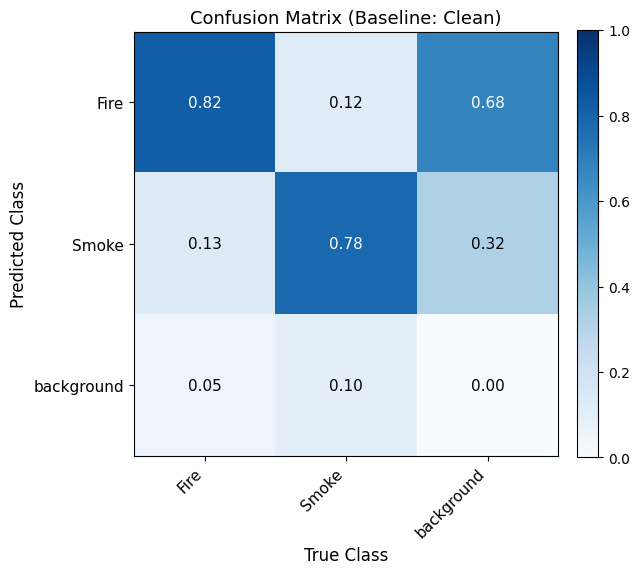

Saved: /kaggle/working/phase5_blanket_seed2024/plots/confusion_matrix_before_clean_normalized.png / .pdf


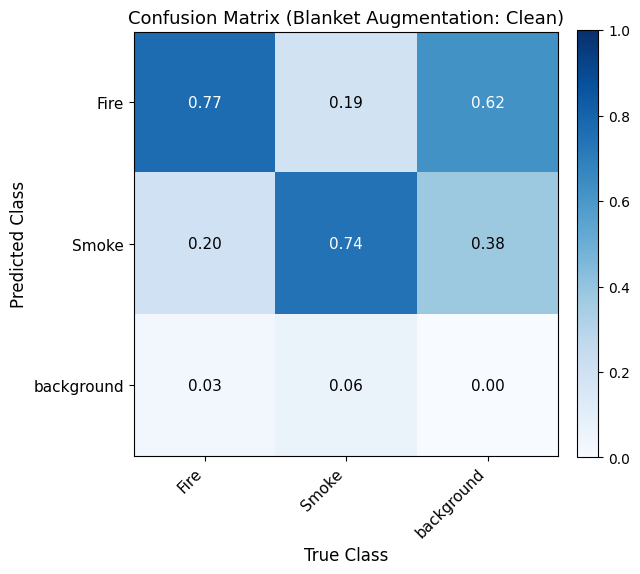

Saved: /kaggle/working/phase5_blanket_seed2024/plots/confusion_matrix_blanket_clean_normalized.png / .pdf

Low-Light severity 4...
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 36.7±9.1 MB/s, size: 45.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/degraded_datasets/low_light/severity_4/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 731.7it/s 2.3s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/degraded_datasets/low_light/severity_4 is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 4.8it/s 22.5s0.2s
                   all       1715       27

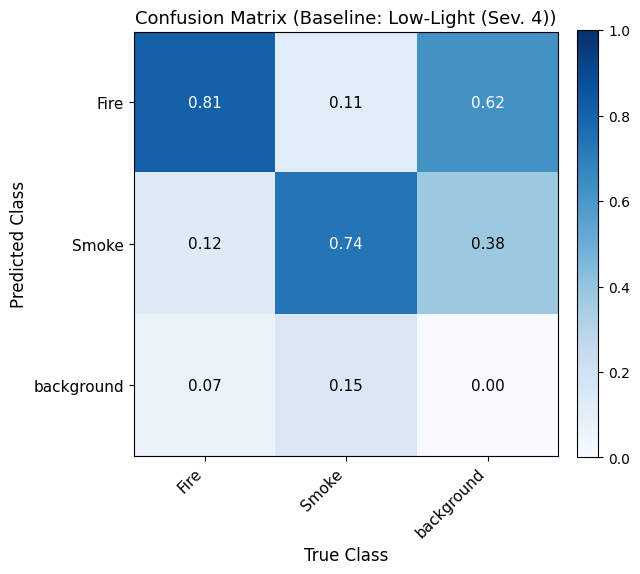

Saved: /kaggle/working/phase5_blanket_seed2024/plots/confusion_matrix_before_lowlight_sev4_normalized.png / .pdf


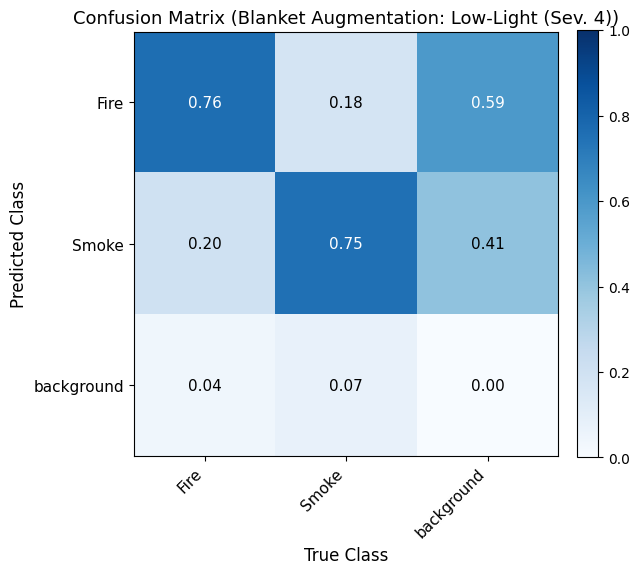

Saved: /kaggle/working/phase5_blanket_seed2024/plots/confusion_matrix_blanket_lowlight_sev4_normalized.png / .pdf

Gaussian Noise severity 4...
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 241.8±68.5 MB/s, size: 297.3 KB)
val: Scanning /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/degraded_datasets/gaussian_noise/severity_4/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 748.1it/s 2.3s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/degraded_datasets/gaussian_noise/severity_4 is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 4.7it/s 23.2s0.2s
                   all       1715       2790      0.664      0.356      0.371      0.276
Speed: 0.9ms preprocess, 9.6ms inference, 0.0ms loss, 0.8ms postprocess per image


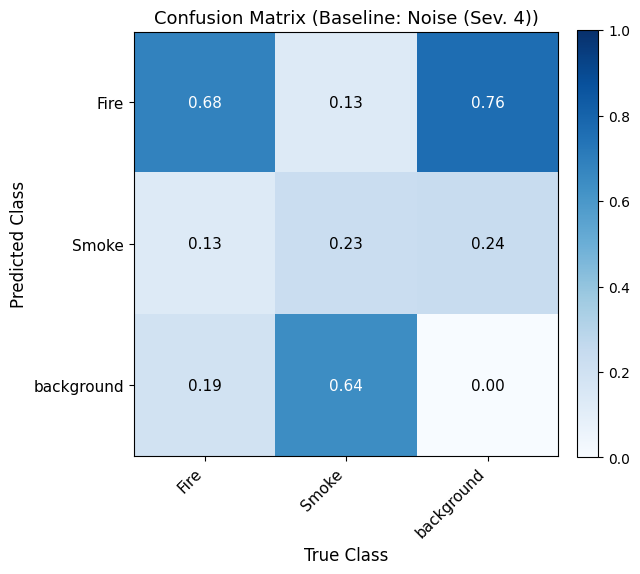

Saved: /kaggle/working/phase5_blanket_seed2024/plots/confusion_matrix_before_noise_sev4_normalized.png / .pdf


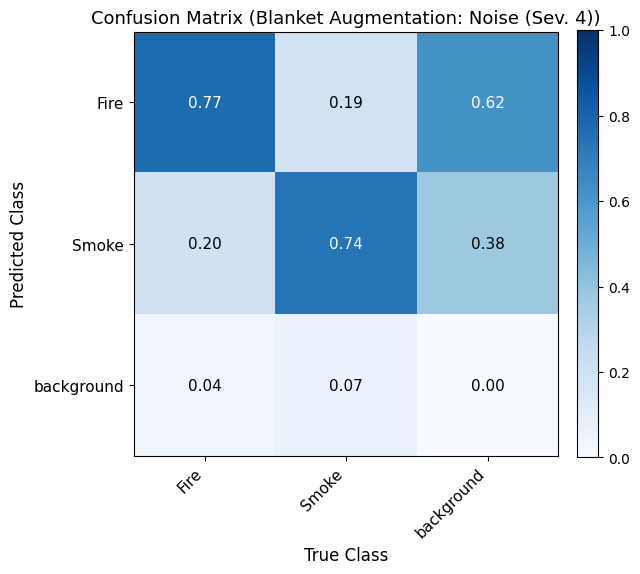

Saved: /kaggle/working/phase5_blanket_seed2024/plots/confusion_matrix_blanket_noise_sev4_normalized.png / .pdf


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def compute_confusion_matrix_df(model, images_dir, name, conf=EVAL_CONF, iou=IOU_THRESHOLD, imgsz=IMG_SIZE):
    yaml_path = os.path.join(LOGS_DIR, f"data_{name}.yaml")
    make_data_yaml(images_dir, yaml_path, CLASS_NAMES)
    temp_plot_dir = os.path.join(LOGS_DIR, f"cm_temp_{name}")
    metrics = model.val(
        data=yaml_path, imgsz=imgsz, conf=conf, iou=iou, split="val",
        device=DEVICE, verbose=False, plots=True, save_json=False,
        project=temp_plot_dir, name="run", exist_ok=True,
    )
    cm = metrics.confusion_matrix.matrix
    n = cm.shape[0]
    labels = CLASS_NAMES + ["background"] if n == len(CLASS_NAMES) + 1 else [f"class_{i}" for i in range(n)]
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_df.index.name = "Predicted"
    cm_df.columns.name = "True"
    return cm_df

def plot_normalized_confusion_matrix(cm_df, title, save_name):
    cm = cm_df.values.astype(float)
    col_sums = cm.sum(axis=0, keepdims=True)
    norm = np.divide(cm, col_sums, out=np.zeros_like(cm), where=col_sums != 0)
    fig, ax = plt.subplots(figsize=(6.5, 6))
    im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    labels = list(cm_df.index)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("True Class", fontsize=12); ax.set_ylabel("Predicted Class", fontsize=12)
    ax.set_title(title, fontsize=13)
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = norm[i, j]
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=11)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(PLOTS_DIR, f"{save_name}.{ext}"), dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {os.path.join(PLOTS_DIR, save_name)}.png / .pdf")

condition_short = {
    "Clean test set": "Clean",
    "Low-Light severity 4": "Low-Light (Sev. 4)",
    "Gaussian Noise severity 4": "Noise (Sev. 4)",
}
conditions_for_cm = [
    ("Clean test set", CLEAN_TEST_IMAGES_DIR, "clean"),
    ("Low-Light severity 4", os.path.join(DEGRADATION_DIRS["Low Light"], "severity_4", "images"), "lowlight_sev4"),
    ("Gaussian Noise severity 4", os.path.join(DEGRADATION_DIRS["Gaussian Noise"], "severity_4", "images"), "noise_sev4"),
]

for label, img_dir, tag in conditions_for_cm:
    if not os.path.isdir(img_dir):
        print(f"Skipping {label}: directory not found.")
        continue
    print(f"\n{label}...")
    cm_before = compute_confusion_matrix_df(before_model, img_dir, f"cm_before_{tag}")
    cm_blanket = compute_confusion_matrix_df(blanket_yolo, img_dir, f"cm_blanket_{tag}")
    cm_before.to_csv(os.path.join(RESULTS_DIR, f"confusion_matrix_before_{tag}.csv"))
    cm_blanket.to_csv(os.path.join(RESULTS_DIR, f"confusion_matrix_blanket_{tag}.csv"))
    short = condition_short.get(label, label)
    plot_normalized_confusion_matrix(cm_before, f"Confusion Matrix ({BEFORE_LABEL}: {short})", f"confusion_matrix_before_{tag}_normalized")
    plot_normalized_confusion_matrix(cm_blanket, f"Confusion Matrix ({BLANKET_LABEL}: {short})", f"confusion_matrix_blanket_{tag}_normalized")

## Cell 10c — Precision-Recall curves (Before vs Blanket)

Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 29.4±15.2 MB/s, size: 29.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/clean_test_set/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 807.1it/s 2.1s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/clean_test_set is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 4.8it/s 22.7s0.2s
                   all       1715       2790      0.869      0.763      0.828      0.625
Speed: 0.9ms preprocess, 9.6ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/phase5_blanket_s

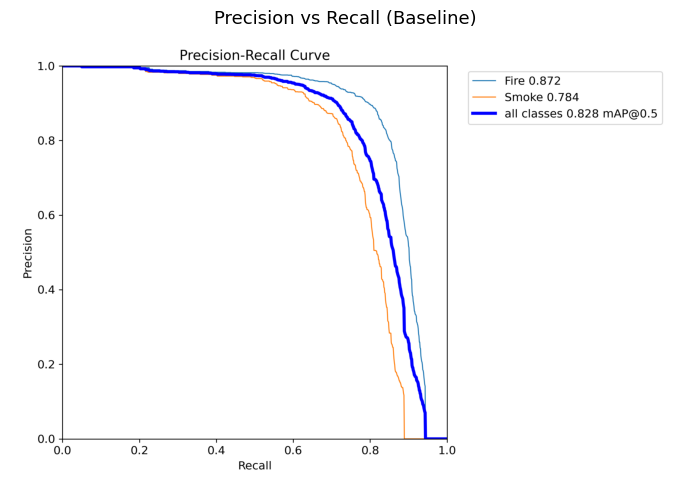

Saved: /kaggle/working/phase5_blanket_seed2024/plots/pr_curve_pr_before_clean.png / .pdf
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 43.7±25.8 MB/s, size: 43.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/clean_test_set/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 790.4it/s 2.2s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/sumiyahaider/dataset-output-phase-3/clean_test_set is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 4.6it/s 23.5s0.2s
                   all       1715       2790      0.875      0.747      0.824      0.621
Speed: 0.9ms preprocess, 9.9ms inference, 

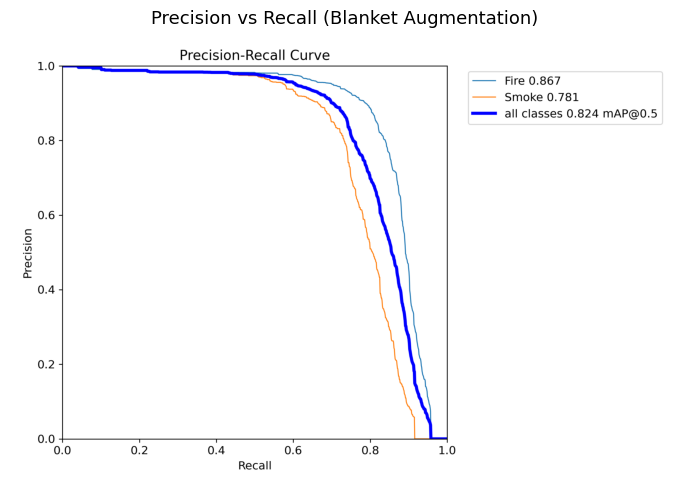

Saved: /kaggle/working/phase5_blanket_seed2024/plots/pr_curve_pr_blanket_clean.png / .pdf


In [13]:
def plot_pr_curve(model, images_dir, name, display_label, conf=0.001, iou=IOU_THRESHOLD, imgsz=IMG_SIZE):
    yaml_path = os.path.join(LOGS_DIR, f"data_{name}.yaml")
    make_data_yaml(images_dir, yaml_path, CLASS_NAMES)
    save_dir = os.path.join(PLOTS_DIR, f"pr_curve_{name}")
    os.makedirs(save_dir, exist_ok=True)
    model.val(
        data=yaml_path, imgsz=imgsz, conf=conf, iou=iou, split="val",
        device=DEVICE, verbose=False, plots=True, save_json=False,
        project=save_dir, name="run", exist_ok=True,
    )
    run_dir = os.path.join(save_dir, "run")
    candidates = ["BoxPR_curve.png", "PR_curve.png"]
    found = None
    for c in candidates:
        p = os.path.join(run_dir, c)
        if os.path.exists(p):
            found = p
            break
    if found is None:
        print(f"WARNING: no PR curve file found in {run_dir}")
        return

    img = plt.imread(found)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Precision vs Recall ({display_label})", fontsize=13, pad=10)
    plt.tight_layout()
    final_path_png = os.path.join(PLOTS_DIR, f"pr_curve_{name}.png")
    final_path_pdf = os.path.join(PLOTS_DIR, f"pr_curve_{name}.pdf")
    plt.savefig(final_path_png, dpi=DPI, bbox_inches="tight")
    plt.savefig(final_path_pdf, dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {final_path_png} / .pdf")

plot_pr_curve(before_model, CLEAN_TEST_IMAGES_DIR, "pr_before_clean", BEFORE_LABEL)
plot_pr_curve(blanket_yolo, CLEAN_TEST_IMAGES_DIR, "pr_blanket_clean", BLANKET_LABEL)


## Cell 10e — Per-class AP50 (Fire vs Smoke, Before vs Blanket)

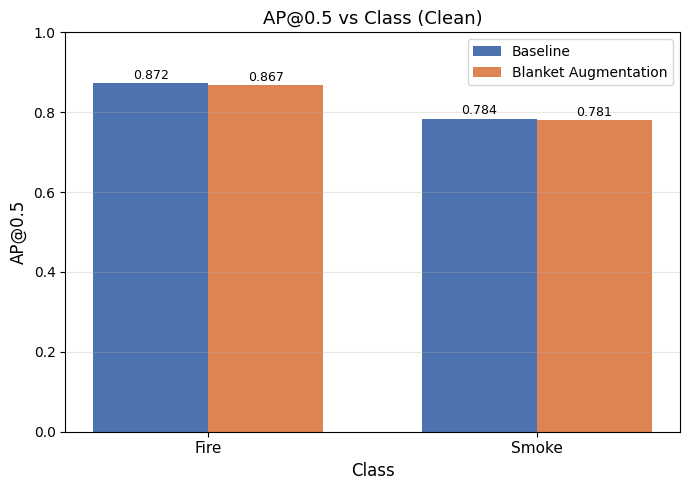

Saved: /kaggle/working/phase5_blanket_seed2024/plots/per_class_ap50_clean.png / .pdf


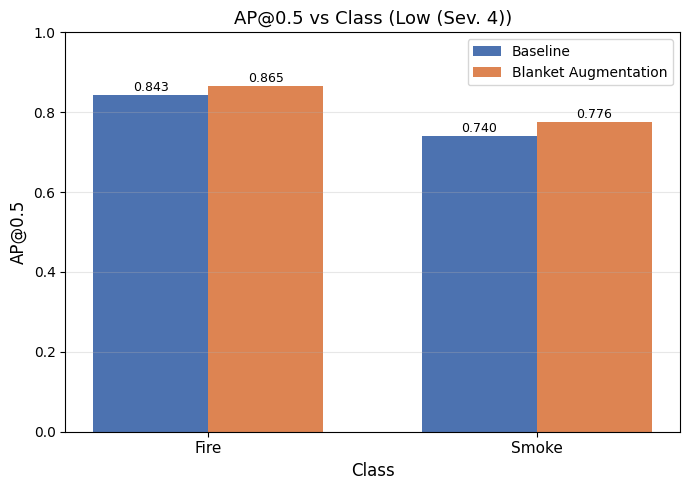

Saved: /kaggle/working/phase5_blanket_seed2024/plots/per_class_ap50_lowlight_sev4.png / .pdf


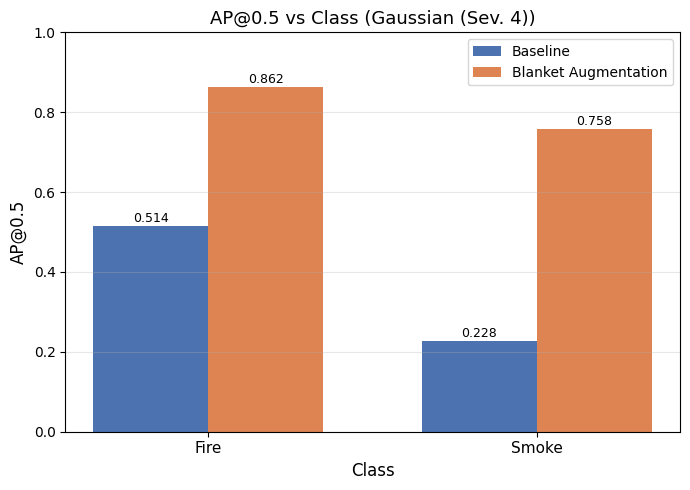

Saved: /kaggle/working/phase5_blanket_seed2024/plots/per_class_ap50_noise_sev4.png / .pdf


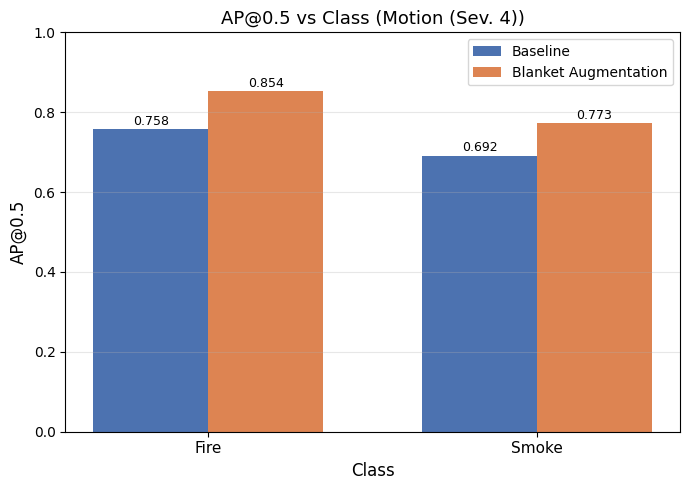

Saved: /kaggle/working/phase5_blanket_seed2024/plots/per_class_ap50_motionblur_sev4.png / .pdf


In [14]:
def plot_per_class_ap_bar(df_before, df_blanket, degradation, severity, save_name):
    row_before = df_before[(df_before["Degradation"] == degradation) & (df_before["Severity"] == severity)]
    row_blanket = df_blanket[(df_blanket["Degradation"] == degradation) & (df_blanket["Severity"] == severity)]
    if row_before.empty or row_blanket.empty:
        print(f"Skipping {save_name}: no data for {degradation} severity {severity}")
        return
    row_before = row_before.iloc[0]
    row_blanket = row_blanket.iloc[0]

    ap_cols = [f"{c}_AP50" for c in CLASS_NAMES]
    before_vals = [row_before.get(c) for c in ap_cols]
    blanket_vals = [row_blanket.get(c) for c in ap_cols]

    x = np.arange(len(CLASS_NAMES))
    width = 0.35
    fig, ax = plt.subplots(figsize=(7, 5))
    bars1 = ax.bar(x - width/2, before_vals, width, label=BEFORE_LABEL, color="#4C72B0")
    bars2 = ax.bar(x + width/2, blanket_vals, width, label=BLANKET_LABEL, color="#DD8452")
    for bars in (bars1, bars2):
        for b in bars:
            h = b.get_height()
            if h is not None:
                ax.annotate(f"{h:.3f}", xy=(b.get_x() + b.get_width() / 2, h),
                            xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, fontsize=11)
    ax.set_xlabel("Class", fontsize=12)
    ax.set_ylabel("AP@0.5", fontsize=12)
    ax.set_ylim(0, 1.0)
    short_cond = "Clean" if degradation == "Clean" else f"{degradation.split()[0]} (Sev. {severity})"
    ax.set_title(f"AP@0.5 vs Class ({short_cond})", fontsize=13)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(PLOTS_DIR, f"{save_name}.{ext}"), dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {os.path.join(PLOTS_DIR, save_name)}.png / .pdf")

plot_per_class_ap_bar(before_df, blanket_df, "Clean", 0, "per_class_ap50_clean")
plot_per_class_ap_bar(before_df, blanket_df, "Low Light", 4, "per_class_ap50_lowlight_sev4")
plot_per_class_ap_bar(before_df, blanket_df, "Gaussian Noise", 4, "per_class_ap50_noise_sev4")
plot_per_class_ap_bar(before_df, blanket_df, "Motion Blur", 4, "per_class_ap50_motionblur_sev4")


## Cell 11 — Comparison table: Before vs Blanket (values only, matches Table 2's format)

In [15]:
merged = before_df.merge(blanket_df, on=["Degradation", "Severity"], suffixes=("_Before", "_Blanket"))

for metric in ["Precision", "Recall", "mAP50", "mAP50_95"]:
    merged[f"{metric}_Improvement_Pct"] = (
        (merged[f"{metric}_Blanket"] - merged[f"{metric}_Before"]) / merged[f"{metric}_Before"].replace(0, np.nan)
    ) * 100.0

comparison_csv = os.path.join(RESULTS_DIR, "before_vs_blanket_comparison.csv")
merged.to_csv(comparison_csv, index=False)
print("Saved:", comparison_csv)

cols = ["Degradation", "Severity",
        "Precision_Before", "Precision_Blanket",
        "Recall_Before", "Recall_Blanket",
        "mAP50_Before", "mAP50_Blanket",
        "mAP50_95_Before", "mAP50_95_Blanket",
        "mAP50_Improvement_Pct"]
print(merged[cols].to_string(index=False))

Saved: /kaggle/working/phase5_blanket_seed2024/results/before_vs_blanket_comparison.csv
   Degradation  Severity  Precision_Before  Precision_Blanket  Recall_Before  Recall_Blanket  mAP50_Before  mAP50_Blanket  mAP50_95_Before  mAP50_95_Blanket  mAP50_Improvement_Pct
         Clean         0          0.869361           0.875484       0.762934        0.747055      0.828040       0.824056         0.625484          0.620516              -0.481161
Gaussian Noise         1          0.855555           0.877190       0.716088        0.746091      0.783998       0.823098         0.590691          0.619373               4.987243
Gaussian Noise         2          0.775929           0.865799       0.576955        0.749219      0.636428       0.823397         0.484954          0.617873              29.377845
Gaussian Noise         3          0.783000           0.865819       0.465214        0.740413      0.516404       0.816383         0.402309          0.612569              58.089856
Gaussian Noi

## Cell 10d — Per-condition metric comparison (Before vs Blanket)

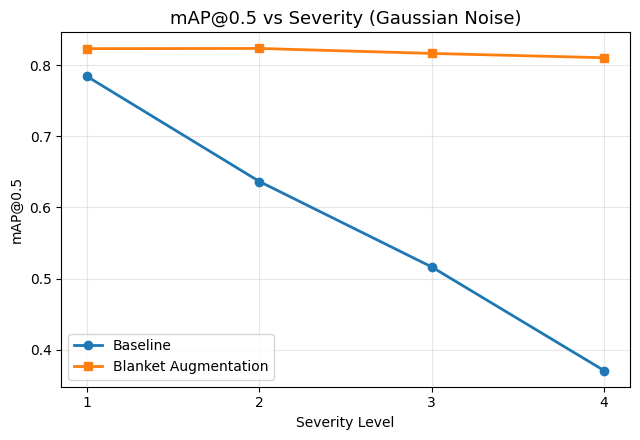

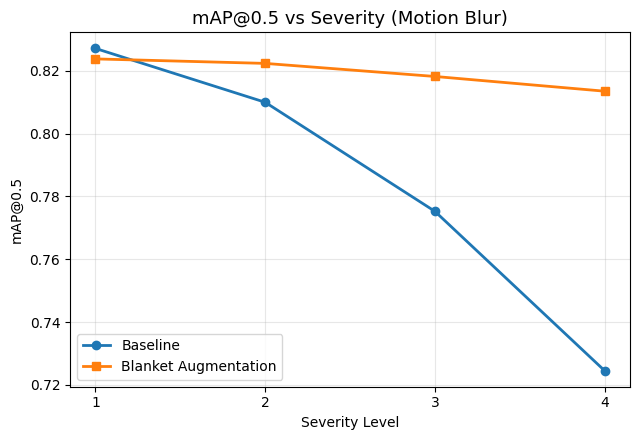

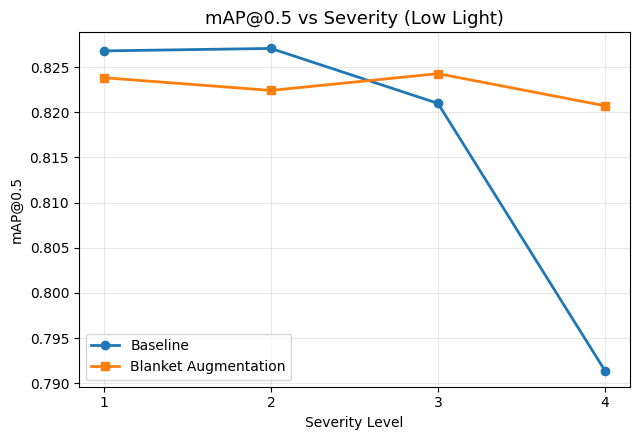

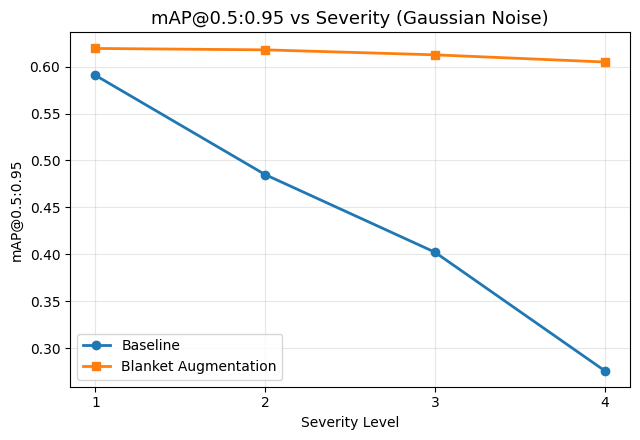

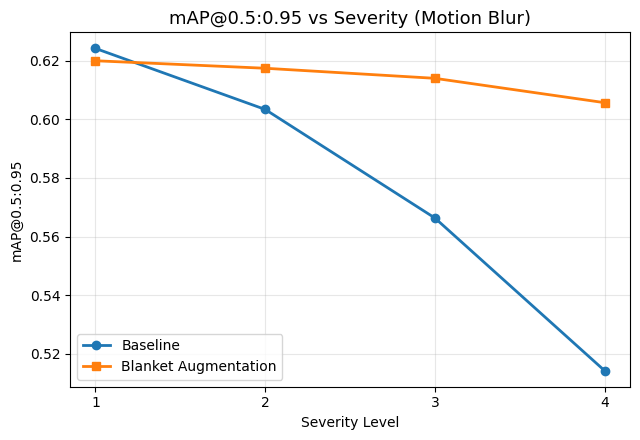

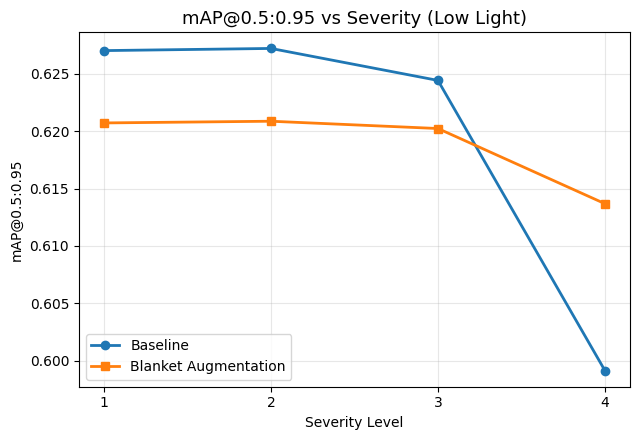

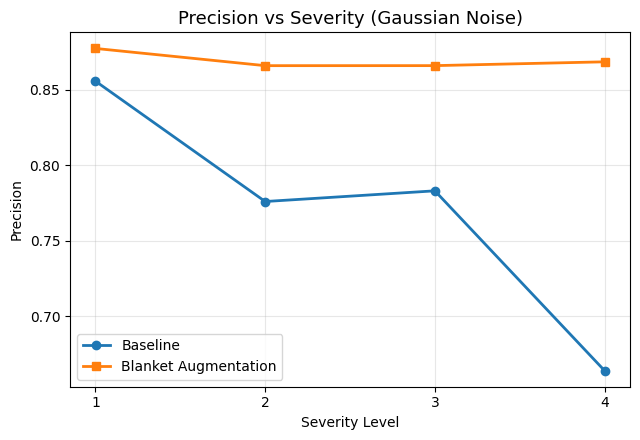

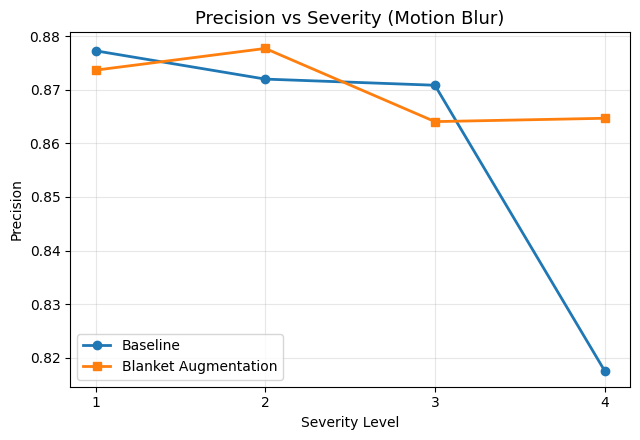

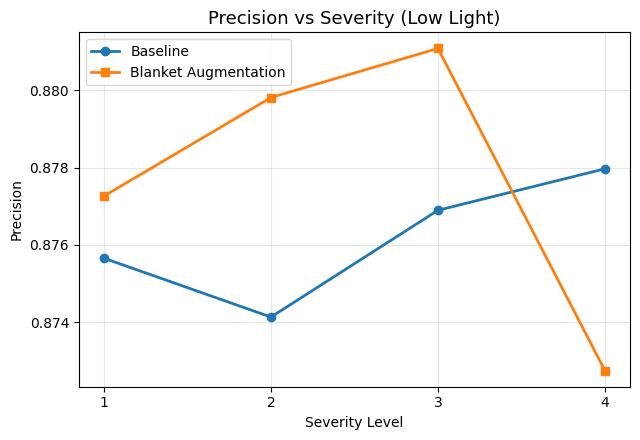

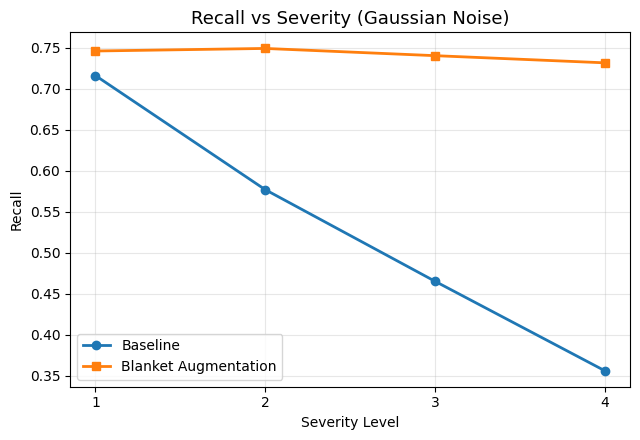

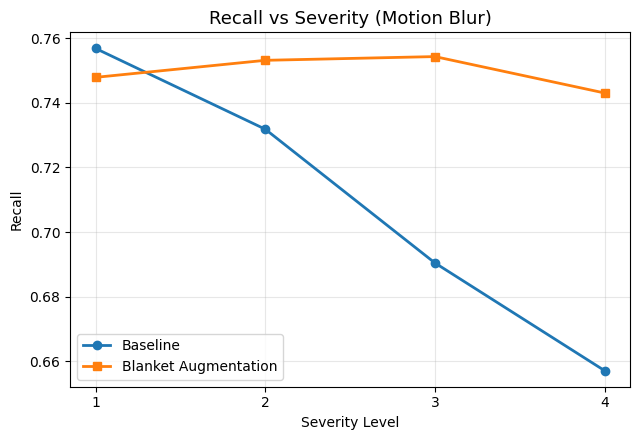

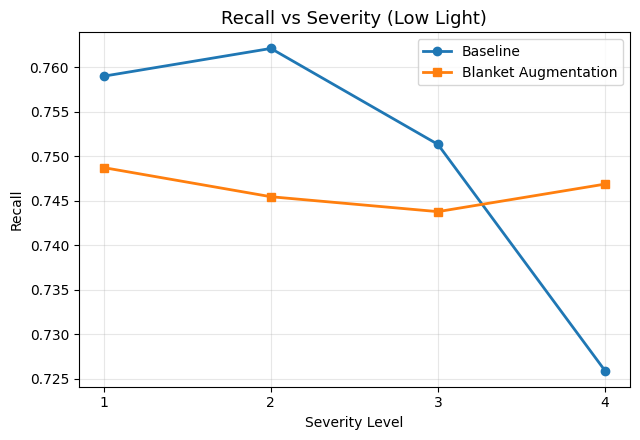

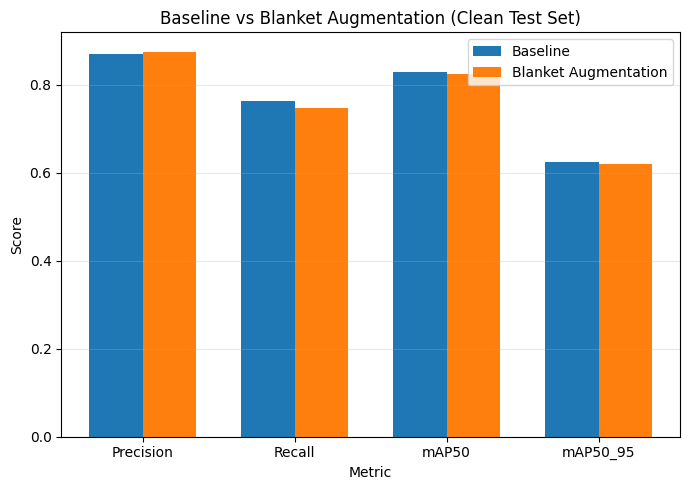

Plots saved to: /kaggle/working/phase5_blanket_seed2024/plots


In [16]:
def plot_metric_comparison(metric, filename_prefix):
    metric_display = {"mAP50": "mAP@0.5", "mAP50_95": "mAP@0.5:0.95",
                       "Precision": "Precision", "Recall": "Recall"}.get(metric, metric)
    for deg in merged["Degradation"].unique():
        if deg == "Clean":
            continue
        sub = merged[merged["Degradation"] == deg].sort_values("Severity")
        plt.figure(figsize=(6.5, 4.5))
        plt.plot(sub["Severity"], sub[f"{metric}_Before"], marker="o", linewidth=2, label=BEFORE_LABEL)
        plt.plot(sub["Severity"], sub[f"{metric}_Blanket"], marker="s", linewidth=2, label=BLANKET_LABEL)
        plt.title(f"{metric_display} vs Severity ({deg})", fontsize=13)
        plt.xlabel("Severity Level")
        plt.ylabel(metric_display)
        plt.xticks(sub["Severity"])
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        safe_deg = deg.replace(" ", "_")
        for ext in ("png", "pdf"):
            plt.savefig(os.path.join(PLOTS_DIR, f"{filename_prefix}_{safe_deg}.{ext}"), dpi=DPI, bbox_inches="tight")
        plt.show()
        plt.close()

for metric in ["mAP50", "mAP50_95", "Precision", "Recall"]:
    plot_metric_comparison(metric, f"before_blanket_{metric.lower()}")

clean_row = merged[merged["Degradation"] == "Clean"]
if not clean_row.empty:
    metrics_list = ["Precision", "Recall", "mAP50", "mAP50_95"]
    before_vals = [clean_row[f"{m}_Before"].values[0] for m in metrics_list]
    blanket_vals = [clean_row[f"{m}_Blanket"].values[0] for m in metrics_list]
    x = np.arange(len(metrics_list))
    width = 0.35
    plt.figure(figsize=(7, 5))
    plt.bar(x - width/2, before_vals, width, label=BEFORE_LABEL)
    plt.bar(x + width/2, blanket_vals, width, label=BLANKET_LABEL)
    plt.xticks(x, metrics_list)
    plt.xlabel("Metric")
    plt.ylabel("Score")
    plt.title(f"{BEFORE_LABEL} vs {BLANKET_LABEL} (Clean Test Set)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(PLOTS_DIR, f"clean_before_blanket.{ext}"), dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close()

print("Plots saved to:", PLOTS_DIR)


## Cell 12 — Save config + ZIP

In [17]:
config = {
    "run_type": "Blanket augmentation (ablation control, no evidence gate)",
    "seed": SEED,
    "before_model_path": BEFORE_MODEL_PATH,
    "blanket_model_path": bundled_blanket_path,
    "training_hyperparameters": {
        "epochs": TRAIN_EPOCHS, "batch": TRAIN_BATCH, "optimizer": TRAIN_OPTIMIZER,
        "lr0": TRAIN_LR0, "seed": TRAIN_SEED,
    },
    "blanket_augmentation": {
        "lowlight_prob": BLANKET_LOWLIGHT_PROB, "lowlight_range": BLANKET_LOWLIGHT_FACTOR_RANGE,
        "noise_prob": BLANKET_NOISE_PROB, "noise_range": BLANKET_NOISE_STD_RANGE,
        "blur_prob": BLANKET_BLUR_PROB, "blur_kernel_range": BLANKET_BLUR_KERNEL_RANGE,
    },
    "class_names": CLASS_NAMES,
}
config_path = os.path.join(OUTPUT_ROOT, "phase5_blanket_config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print("Saved:", config_path)

zip_path = shutil.make_archive(f"/kaggle/working/phase5_blanket_results_seed{SEED}", "zip", OUTPUT_ROOT)
print("\nFINAL ZIP:")
print(" ", zip_path)

Saved: /kaggle/working/phase5_blanket_seed2024/phase5_blanket_config.json

FINAL ZIP:
  /kaggle/working/phase5_blanket_results_seed2024.zip
